In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc

seed = 52

CWD = os.getcwd()
DATA_PATH = os.path.join(CWD, 'filtered_feature_bc_matrix')
CELLANNO_PATH = os.path.join(CWD, 'cell_annotations.tsv')

In [2]:
# Load data
adata =sc.read_10x_mtx(DATA_PATH, gex_only=True)
# Filter features that are detected in less than 10 cells
sc.pp.filter_genes(adata, min_cells=10)

In [3]:
# Compute quality control metrics
adata.var['mt'] = adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'],log1p=False, percent_top=None, inplace=True)

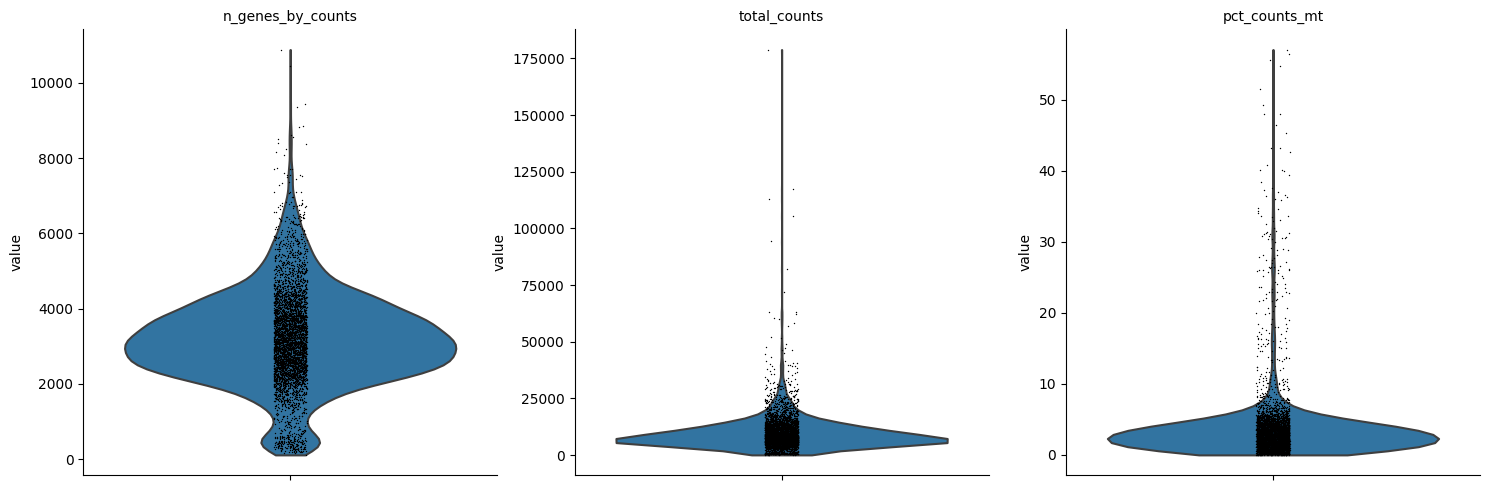

In [4]:
# Plot quality control metrics
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts',  'pct_counts_mt'], jitter = 0.04, 
             multi_panel= True)

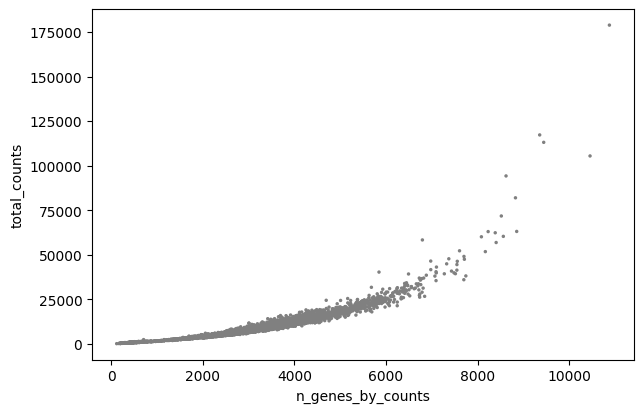

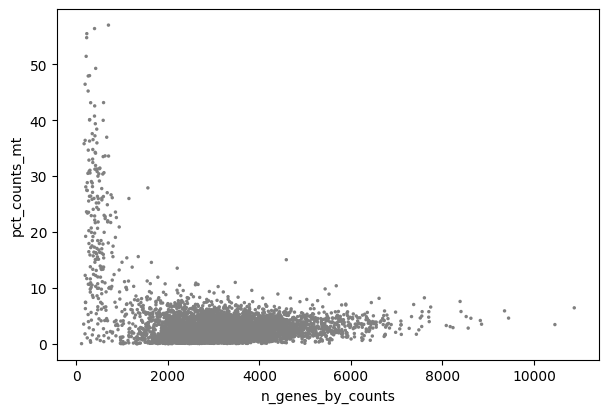

In [5]:
sc.pl.scatter(adata, x='n_genes_by_counts', y='total_counts')
sc.pl.scatter(adata, x='n_genes_by_counts', y='pct_counts_mt')

In [6]:
# Filtering 
lower, upper = np.percentile(adata.obs.n_genes_by_counts, [2, 98]).astype(int)
adata = adata[adata.obs.n_genes_by_counts>lower]
adata = adata[adata.obs.n_genes_by_counts<upper]
adata = adata[adata.obs.pct_counts_mt < 5]

In [7]:
# Normalization and log transformation
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

c:\Users\aless\Desktop\scVEMO\lib\site-packages\scanpy\preprocessing\_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


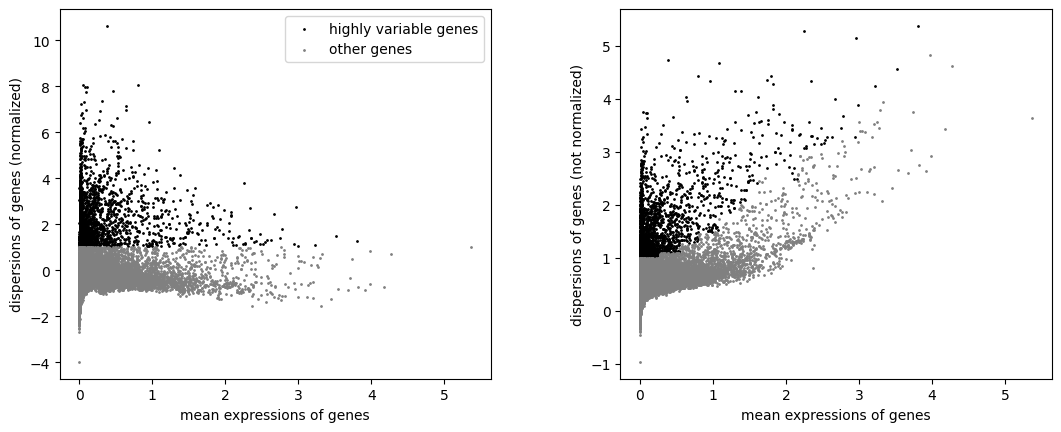

In [8]:
# Compute highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pl.highly_variable_genes(adata)

In [9]:
# Scaling data
sc.pp.scale(adata)

In [10]:
# Saving preprocessed file
adata.write_h5ad(os.path.join(CWD, "10xMouse_preprocessed.h5ad"))

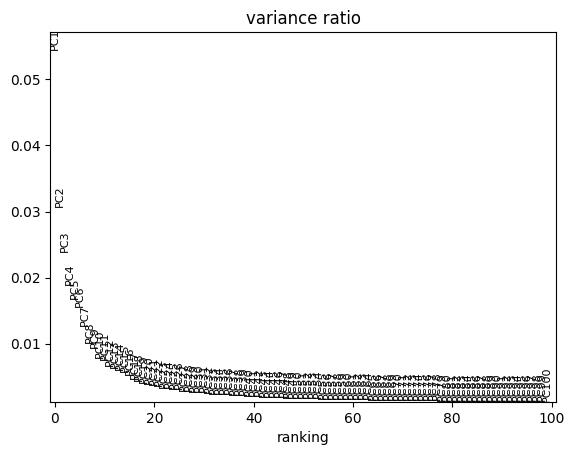

In [11]:
# PCA
sc.tl.pca(adata, n_comps = 100, use_highly_variable=True)
sc.pl.pca_variance_ratio(adata, n_pcs=100)

In [12]:
# Setting parameters
pcs = 30 #From elbow plot
k = int(adata.n_obs**(1/2)) # Rule of thumb for KNN

In [13]:
# Computing Neighbors and UMAP
sc.pp.neighbors(adata, n_neighbors=k, n_pcs=pcs)
sc.tl.umap(adata)

c:\Users\aless\Desktop\scVEMO\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
# Louvain community detection algorithm
sc.tl.louvain(adata, random_state=seed)

c:\Users\aless\Desktop\scVEMO\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


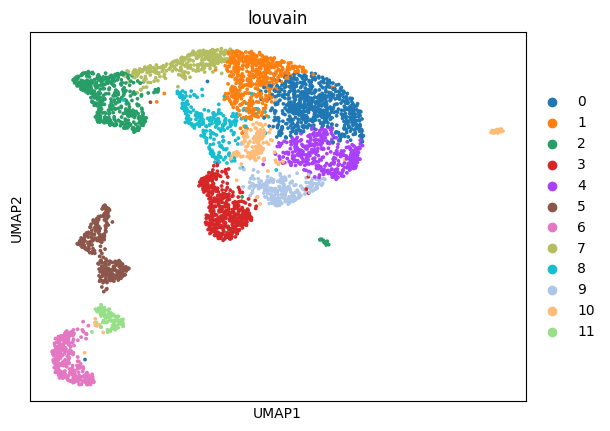

In [15]:
# Plot UMAP with Louvain communities
sc.pl.umap(adata, color=['louvain'])

In [16]:
# Load cell annotations from Multivelo Github 
# https://github.com/welch-lab/MultiVelo/tree/main/Examples
cell_annotations = pd.read_csv(CELLANNO_PATH, sep='\t', header=0, index_col=0)
common_barcodes = set(cell_annotations.index).intersection(set(adata.obs_names))
print(f"Detected {len(common_barcodes)} common barcodes < {len(adata.obs_names)}: creating subset ...")

Detected 3904 common barcodes < 4084: creating subset ...


c:\Users\aless\Desktop\scVEMO\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


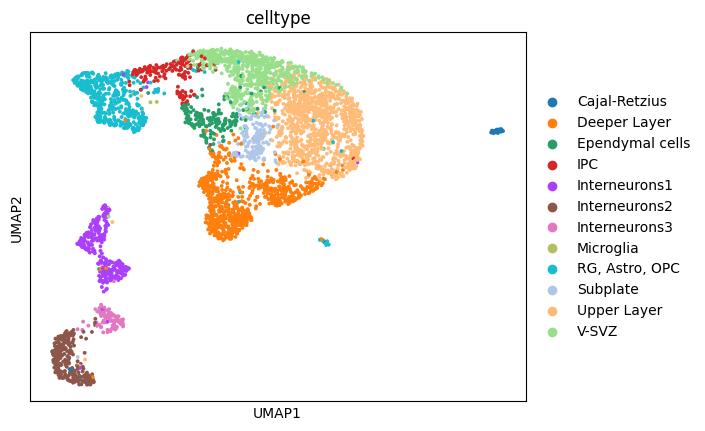

In [17]:
# Visual inspection of Multivelo Clusters
adata = adata[adata.obs_names.isin(cell_annotations.index)]
adata.obs = adata.obs.join(cell_annotations, how='left')
sc.pl.umap(adata, color=['celltype'])